# IV surface diagnostics

This notebook interrogates the IV-analysis panel before any surface fitting. It separates valid midpoint IV observations from failed inversions, compares calculated IV with the vendor benchmark, and inspects raw OTM smiles and quote quality.

No smoothing, interpolation, liquidity filter, or surface model is applied here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PANEL_PATH = Path("../data/processed/spx_iv_panel_2025-08-29.csv")
panel = pd.read_csv(PANEL_PATH, parse_dates=["quote_date", "expiry_date"])
panel.shape

(14852, 29)

## 1. IV inversion coverage

Start with the number of observations produced by the panel:

$$
N_{\mathrm{panel}},\quad N_{\mathrm{valid\ IV}},\quad N_{\mathrm{invalid\ IV}},\quad N_{\mathrm{OTM}},\quad N_{\mathrm{surface}}.
$$

A failed inversion is retained as `mid_iv = NaN`; it is not treated as a liquidity filter. The breakdowns below show whether failures are concentrated by option type, time to expiry, or log-moneyness.

In [2]:
summary = pd.Series({
    "N_panel": len(panel),
    "N_valid_IV": panel["mid_iv"].notna().sum(),
    "N_invalid_IV": panel["mid_iv"].isna().sum(),
    "N_OTM": panel["is_otm"].sum(),
    "N_use_for_surface": panel["use_for_surface"].sum(),
})
summary

N_panel              14852
N_valid_IV           14453
N_invalid_IV           399
N_OTM                 7426
N_use_for_surface     7426
dtype: int64

In [3]:
failed_iv = panel[panel["mid_iv"].isna()].copy()
failed_iv["dte_bucket"] = pd.cut(
    failed_iv["days_to_expiry"],
    bins=[0, 7, 30, 90, 365, np.inf],
    labels=["1-7", "8-30", "31-90", "91-365", "366+"],
)
failed_iv["moneyness_bucket"] = pd.cut(
    failed_iv["log_moneyness"],
    bins=[-np.inf, -0.2, -0.05, 0.05, 0.2, np.inf],
    labels=["deep_put_wing", "put_side", "near_ATM", "call_side", "deep_call_wing"],
)
failure_by_type = failed_iv.groupby("option_type", observed=True).size().rename("n_failures")
failure_by_dte = failed_iv.groupby("dte_bucket", observed=True).size().rename("n_failures")
failure_by_moneyness = failed_iv.groupby("moneyness_bucket", observed=True).size().rename("n_failures")
failure_by_type, failure_by_dte, failure_by_moneyness

(option_type
 call    340
 put      59
 Name: n_failures, dtype: int64,
 dte_bucket
 1-7       216
 8-30      127
 31-90      47
 91-365      9
 Name: n_failures, dtype: int64,
 moneyness_bucket
 deep_put_wing     202
 put_side          124
 near_ATM           64
 call_side           1
 deep_call_wing      8
 Name: n_failures, dtype: int64)

## 2. Calculated IV versus vendor IV

For observations where both values exist, compare

$$
\Delta\sigma=\sigma_{\mathrm{mid}}-\sigma_{\mathrm{vendor}}.
$$

The values need not agree exactly because the vendor may use different forwards, discounting, prices, conventions, or filters. We are looking for gross disagreement, bias, and obvious outliers.

In [4]:
comparison = panel.dropna(subset=["mid_iv", "vendor_iv"]).copy()
comparison["iv_difference"] = comparison["mid_iv"] - comparison["vendor_iv"]
comparison[["mid_iv", "vendor_iv", "iv_difference"]].describe()

,mid_iv,vendor_iv,iv_difference
count,13326.000000,13326.000000,13326.000000
mean,0.208936,0.209508,-0.000572
std,0.165722,0.166655,0.017892
min,0.034800,0.046791,-0.198794
25%,0.116926,0.118383,-0.001500
50%,0.163016,0.163086,-0.000431
75%,0.241533,0.236172,0.002017
max,2.943162,2.943847,0.151143


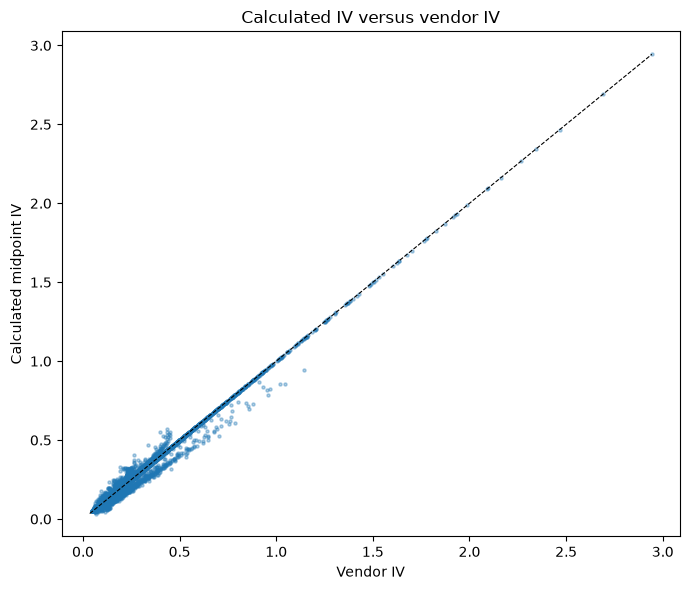

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(comparison["vendor_iv"], comparison["mid_iv"], s=5, alpha=0.35)
limits = [
    min(comparison["vendor_iv"].min(), comparison["mid_iv"].min()),
    max(comparison["vendor_iv"].max(), comparison["mid_iv"].max()),
]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Vendor IV")
ax.set_ylabel("Calculated midpoint IV")
ax.set_title("Calculated IV versus vendor IV")
plt.tight_layout()

## 3. Raw OTM smiles

Use only observations marked `use_for_surface` and plot the calculated IV against log-moneyness:

$$
k=\log(K/F),\qquad \sigma=\sigma_{\mathrm{mid}}.
$$

The selected expiries represent short, intermediate, and long maturities. These are raw scatter plots: no curve is fitted and no smoothing is applied. We want to see whether the smiles are broadly coherent before choosing a surface model.

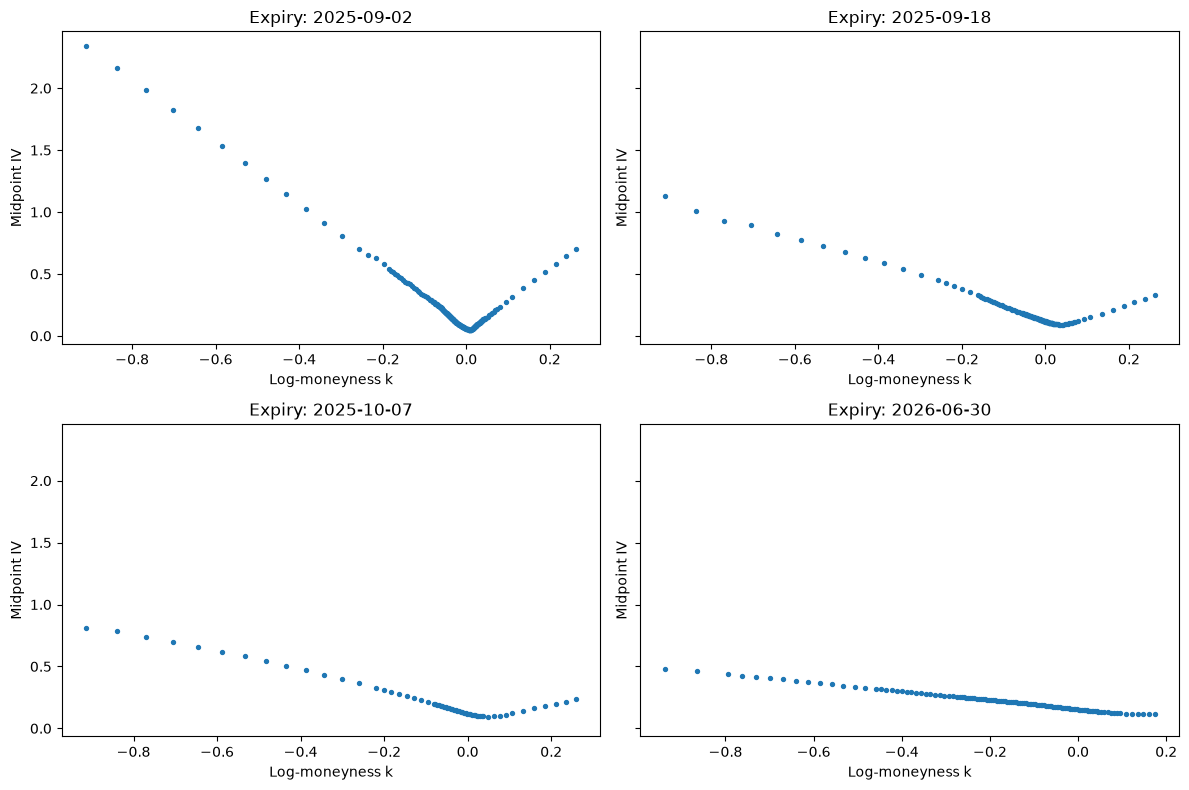

In [6]:
surface_rows = panel[panel["use_for_surface"]].copy()
expiry_dates = surface_rows["expiry_date"].drop_duplicates().sort_values()
selected_expiries = expiry_dates.iloc[np.linspace(0, len(expiry_dates) - 1, 4).round().astype(int)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, expiry in zip(axes.flat, selected_expiries):
    sample = surface_rows[surface_rows["expiry_date"] == expiry]
    ax.scatter(sample["log_moneyness"], sample["mid_iv"], s=8)
    ax.set_title(f"Expiry: {expiry.date()}")
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Midpoint IV")

plt.tight_layout()

## 4. Quote quality around the usable observations

If the raw smiles contain spikes or discontinuities, relate them back to the original quote fields. The following views expose midpoint IV, relative spread, volume, open interest, and the difference from the vendor IV without imposing a cutoff.

This is the point at which we can decide whether zero bids, wide spreads, or a moneyness range explain the problematic observations. No such rule is applied in this notebook.

In [7]:
surface_rows[["mid_iv", "relative_spread", "volume", "open_interest"]].describe()

,mid_iv,relative_spread,volume,open_interest
count,7426.000000,7426.000000,7426.000000,7426.000000
mean,0.232277,0.193616,125.773903,492.496633
std,0.204115,0.466916,620.008127,3075.428761
min,0.049059,0.000000,0.000000,0.000000
25%,0.118413,0.007859,0.000000,17.000000
50%,0.170789,0.019048,3.000000,76.000000
75%,0.264192,0.074074,31.000000,244.000000
max,2.943162,2.000000,20747.000000,73690.000000


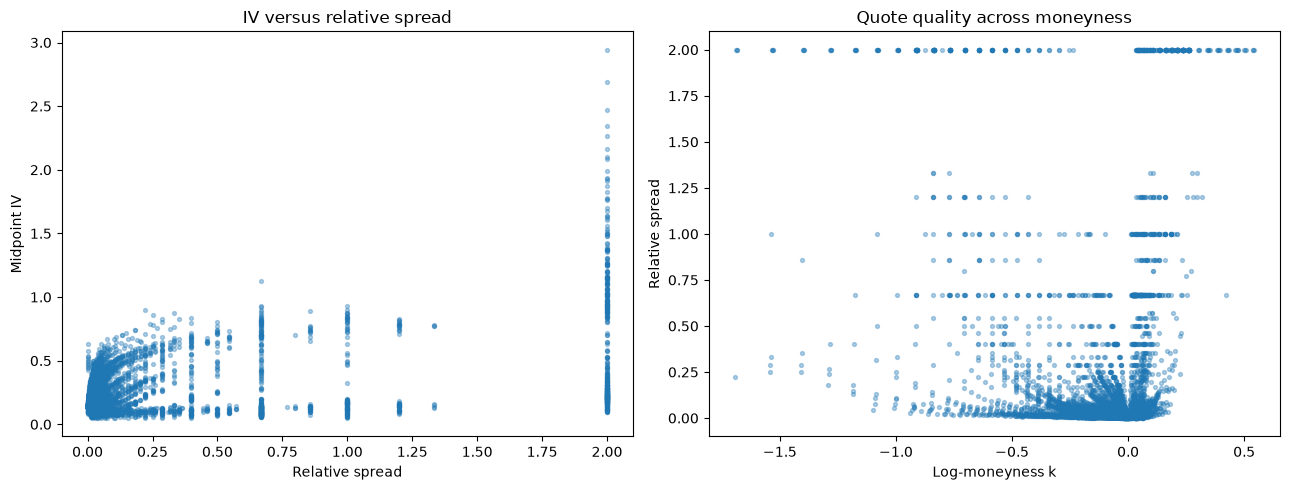

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(surface_rows["relative_spread"], surface_rows["mid_iv"], s=8, alpha=0.35)
axes[0].set_xlabel("Relative spread")
axes[0].set_ylabel("Midpoint IV")
axes[0].set_title("IV versus relative spread")
axes[1].scatter(surface_rows["log_moneyness"], surface_rows["relative_spread"], s=8, alpha=0.35)
axes[1].set_xlabel("Log-moneyness k")
axes[1].set_ylabel("Relative spread")
axes[1].set_title("Quote quality across moneyness")
plt.tight_layout()